## FTS GC pipeline 

This notebook reads experiment metadata from `FTS_Robin_metadata.yaml`, builds a chromstream `Experiment` from the `chromatograms/` folder declared in the metadata, integrates peaks using the peak windows in the metadata, converts areas to amounts, applies an internal-standard correction, parses reactor log files with `chromstream.parsers.parse_log_file`, and merges results.

Edit `current_experiment` to select a different experiment from the YAML. Make sure the `root` and `folder_name` entries in the metadata point to actual paths on disk.

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib widget
# Imports
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import chromstream as cs
import FTS_Analysis_GC as fts


### Metadata
Selecting the experiment from the metadata. This contain the information for the script including the path where the data is stored, reactant concentrations, which internal standaard and also the peak intergration values that can be used later.

In [3]:
import os
import yaml
all_metadata = fts.load_experiment_metadata(r'C:/Users/6855245/OneDrive - Universiteit Utrecht/PhD/Results/FTS catalytic tests/Processed_data/raw_data/FTS_Robin_metadata.yaml')

# Load the metadata for the current experiment
current_experiment = 'RCI_AGL_PVL_006_FTS_Co10TiO2'
setup = all_metadata[current_experiment]['setup']
metadata = all_metadata[current_experiment]

print('Metadata overview')
print('=================')
print(f"Directory:          {metadata['root']}{metadata['folder_name']}")
print(f"Experiment:         {metadata['experiment_name']}")
print(f"Information:        {metadata['description']}")
print(f"                    {metadata['notes']}")
print('') 
print(f"Experiment type:    {metadata['experiment_type']}")
print(f"Setup:              {metadata['setup']}")
print(f"Pretreatment:       {metadata['pretreatment']}")
print(f"Catalyst:           {metadata['catalyst']['catalyst_code']}")
print('')
print(f"Experiment:         {current_experiment}")
print(f"Reactants:          {metadata['reactant_conc']}")
print(f"Internal Standard:  {metadata['IntStand']} ({metadata['ISConc']})")
print(f"Catalyst:           {metadata['catalyst']}")


Metadata overview
Directory:          C:/Users/6855245/OneDrive - Universiteit Utrecht/PhD/Results/FTS catalytic tests/Processed_data/raw_data/20250428-AGL-PVL-Co10TiO2-20Bar-10CO_20H2_3Ar_7N2-410Red-220FTS/
Experiment:         20250428-AGL-PVL-Co10TiO2-20Bar-10CO_20H2_3Ar_7N2-410Red-220FTS/
Information:        FTS with Co10/TiO2 - Steady state,
                    Reduction at 410C, Co10TiO2 catalyst at 20 Barg, 50 hours on stream, 10CO, 20H2, 3Ar, 7N2, 220C, 50Hours,

Experiment type:    FTS
Setup:              FTGC
Pretreatment:       H2, N2
Catalyst:           Co10TiO2

Experiment:         RCI_AGL_PVL_006_FTS_Co10TiO2
Reactants:          {'CO': 0.25, 'CO2': 0.0, 'H2': 0.5, 'Ar': 0.075, 'N2': 0.175, 'He': 0}
Internal Standard:  Ar (0.075)
Catalyst:           {'metal': 'Co', 'support': 'TiO2', 'promoter': None, 'catalyst_code': 'Co10TiO2', 'Co_loading': 10, 'weight': 0.23448}


### Sets up and load an FTS experiment's GC data

It defines the data folder paths, initializes an `Experiment` object, and either adds all chromatograms once using `.add_chromatogram()` followed by `.save_to_csv()` to extract and store the parsed data (takes approxamately 60 sec depending on the number of injections), or simply reloads the processed data later using `.load_from_csv()` without re-parsing the raw files.
After loading, it summarizes how many GC files and injections were found, and prints the experiment’s start time.

In [4]:
# Define the path to the data folder
data_home = Path(metadata['root']) / metadata['folder_name']
gc_path = data_home / metadata['gc']
gc_files = sorted((gc_path).iterdir())
experiment_name = metadata["experiment_name"]
# Initialize an Experiment
exp_full = cs.Experiment(current_experiment)

# True = read chromatograms and make one big file
# False = only read the files once already made 
process_raw = False
if process_raw:
    for chrom_path in gc_files:
        exp_full.add_chromatogram(chrom_path)  # adding each chromatograms to the experiment
    exp_full.save_to_csv(data_home)
else:
    exp_full.load_from_csv(data_home)
injections = (max((len(exp_full.channels[ch].chromatograms) for ch in getattr(exp_full, 'channel_names', [])), default=0))
exp_full.experiment_starttime = next(iter(next(iter(exp_full.channels.values())).chromatograms.values())).injection_time
print(f'Found {len(gc_files)} files in {gc_path}')
print(f'Found {injections} injections in {len(exp_full.channel_names)} channnels: {exp_full.channel_names}')  # summary of the experiment
print("Date/time of the GC start: " + str(exp_full.experiment_starttime))

✅ Loaded channel 'FID' from C:\Users\6855245\OneDrive - Universiteit Utrecht\PhD\Results\FTS catalytic tests\Processed_data\raw_data\20250428-AGL-PVL-Co10TiO2-20Bar-10CO_20H2_3Ar_7N2-410Red-220FTS\RCI_AGL_PVL_006_FTS_Co10TiO2_FID.csv
✅ Loaded channel 'TCD_AuxLeft' from C:\Users\6855245\OneDrive - Universiteit Utrecht\PhD\Results\FTS catalytic tests\Processed_data\raw_data\20250428-AGL-PVL-Co10TiO2-20Bar-10CO_20H2_3Ar_7N2-410Red-220FTS\RCI_AGL_PVL_006_FTS_Co10TiO2_TCD_AuxLeft.csv
✅ Loaded channel 'TCD_AuxRight' from C:\Users\6855245\OneDrive - Universiteit Utrecht\PhD\Results\FTS catalytic tests\Processed_data\raw_data\20250428-AGL-PVL-Co10TiO2-20Bar-10CO_20H2_3Ar_7N2-410Red-220FTS\RCI_AGL_PVL_006_FTS_Co10TiO2_TCD_AuxRight.csv
Found 348 files in C:\Users\6855245\OneDrive - Universiteit Utrecht\PhD\Results\FTS catalytic tests\Processed_data\raw_data\20250428-AGL-PVL-Co10TiO2-20Bar-10CO_20H2_3Ar_7N2-410Red-220FTS\chromatograms
Found 116 injections in 3 channnels: ['FID', 'TCD_AuxLeft', 'T

#### Plotting channels and highlighting peaks
This code automatically extracts all peak integration limits from the experiment metadata, summarizes them in a compact table, and plots each GC channel with its defined peaks highlighted. The plots let you visually check whether the integration windows correctly capture each compound.
You can use for plotting either:

• `ch_obj.plot(show_peaks=True, peak_dict=peak_dict)` — to overlay integration regions on each chromatogram, or

• `exp_full.plot_chromatograms()` — for a simpler view without peak annotations.

Peak Name    | Integration Limits        | Channel     
------------------------------------------------------------
C1           | [1.85, 1.895]             | FID         
C2           | [1.895, 1.95]             | FID         
C3           | [2.0, 2.26]               | FID         
C4           | [2.32, 2.73]              | FID         
C5           | [2.74, 3.4]               | FID         
C6           | [5.25, 5.8]               | FID         
CO2          | [2.1, 2.4]                | TCD_AuxLeft 
CO           | [7.75, 9.5]               | TCD_AuxLeft 
Ar           | [5.48, 5.9]               | TCD_AuxLeft 
N2           | [5.9, 6.43]               | TCD_AuxLeft 
H2           | [2.2, 2.7]                | TCD_AuxRight


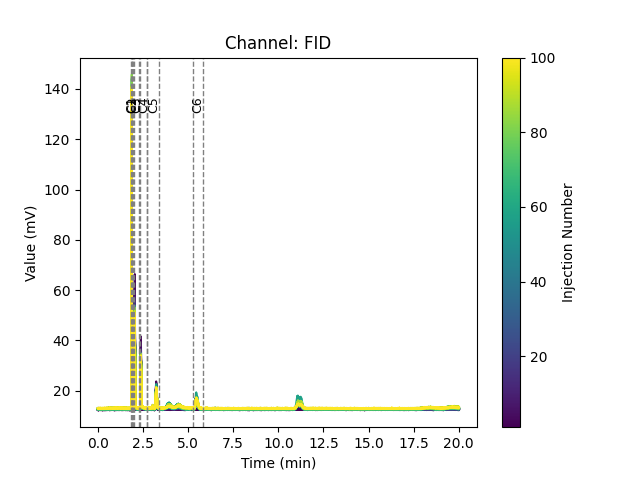

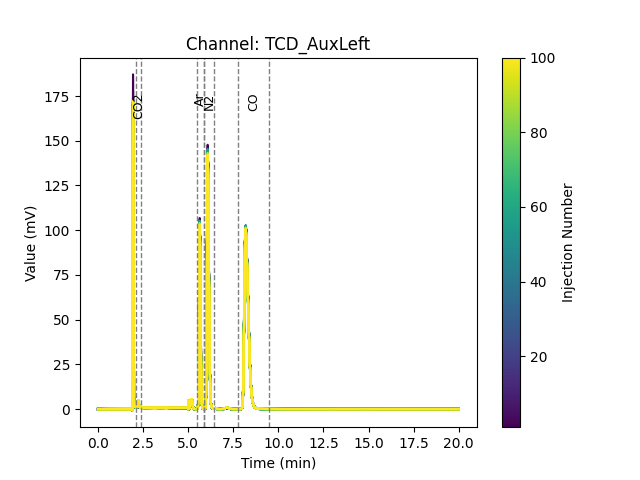

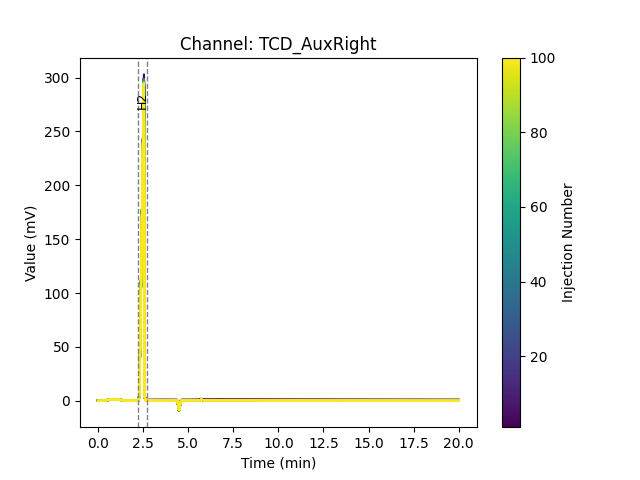

In [5]:
# Load metadata and extract current experiment info
all_metadata = fts.load_experiment_metadata(r'C:/Users/6855245/OneDrive - Universiteit Utrecht/PhD/Results/FTS catalytic tests/Processed_data/raw_data/FTS_Robin_metadata.yaml')
metadata = all_metadata[current_experiment]

# Automatically extract all peak definitions for each channel
peak_dict = {channel: {compound: vals['range'] for compound, vals in peaks.items()} for channel, peaks in metadata.items() 
             if isinstance(peaks, dict) and all(isinstance(v, dict) for v in peaks.values())}

# Flatten all peaks for overview table and compound list
all_peaks = [(compound, limits, channel) for channel, peaks in peak_dict.items() for compound, limits in peaks.items()]
compound_list = [compound for compound, _, _ in all_peaks]

# Print summary table
print(f"{'Peak Name':<12} | {'Integration Limits':<25} | {'Channel':<12}")
print("-" * 60)
for compound, limits, channel in all_peaks:
    print(f"{compound:<12} | {str(limits):<25} | {channel:<12}")

# Plot chromatograms for each channel
for channel, ch_obj in exp_full.channels.items():
    ch_obj.plot(show_peaks=True, peak_dict=peak_dict, injection_range=(1, 100))



### Load log file during experiment
This code loads and processes the reactor log files containing flow and pressure data, filters for relevant sampling events (`Valve 9 == 1`), and calculates the total gas flow by summing all MFC signals.

It then visualizes the reactor conditions using `exp_full.plot_logFT()`.
By setting `use_exp_time=True`, the plot’s x-axis is shown as experiment time (TOS – time on stream) instead of raw timestamps, allowing you to directly compare log trends with GC results over reaction time.

You can also set `use_exp_time=False` to plot against absolute datetime if preferred.

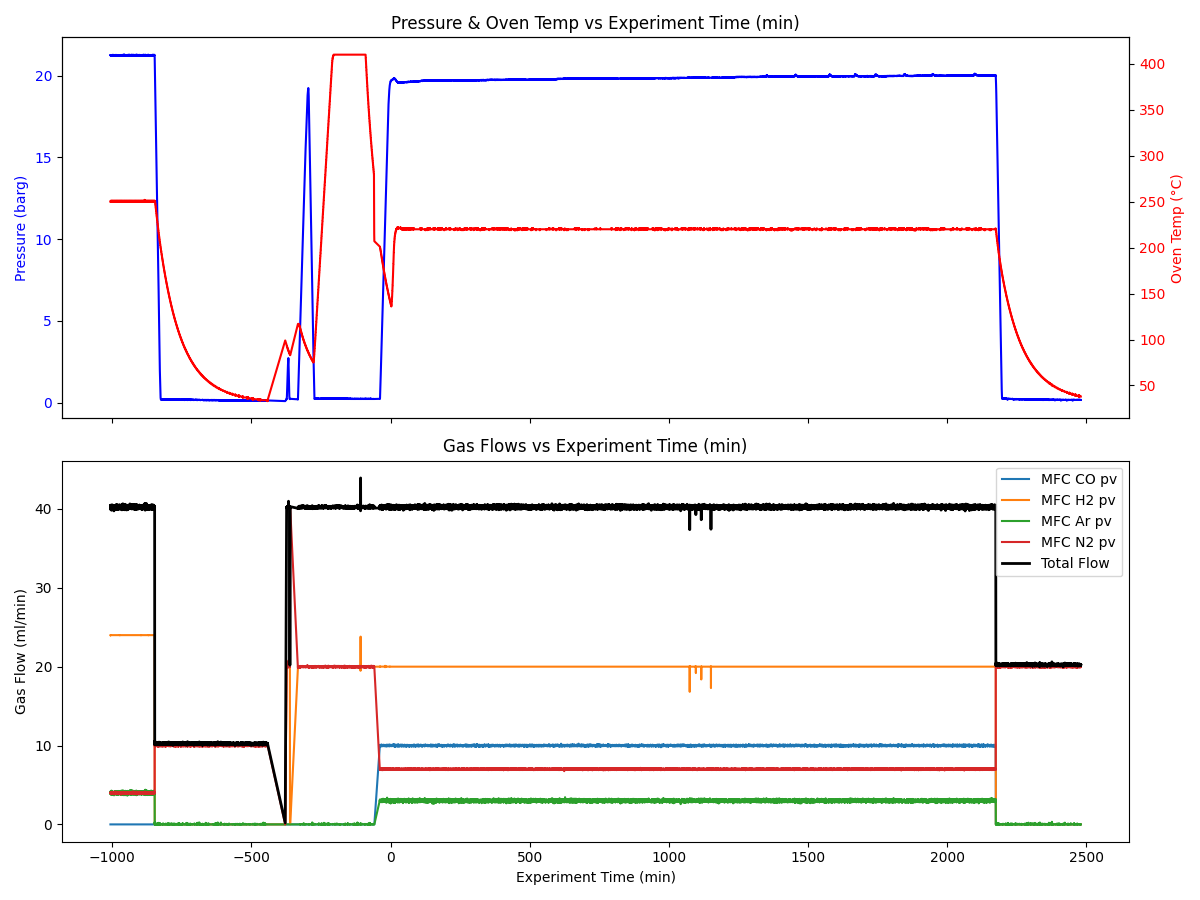

In [6]:
log_path = data_home / metadata['logfile']
exp_full.add_log(pd.concat([cs.parse_log_file(lf) for lf in sorted(log_path.iterdir())], ignore_index=True))
exp_full.log = exp_full.log[exp_full.log['Valve 9'] == 1].drop(columns=['Valve 9'])
mfc_columns = [col for col in exp_full.log.columns if 'MFC' in col and 'pv' in col and 'Call' not in col]
exp_full.log['Total Flow'] = exp_full.log[mfc_columns].sum(axis=1)  # Calculate total flow
static_columns = ['Oven PV', 'Pressure R1', 'Pressure R2', 'BPC A-SP', 'MFM','Total Flow']
selected_columns = static_columns + mfc_columns
exp_full.plot_logFT(gases=['CO', 'H2', 'Ar', 'N2'], use_exp_time=True)




## Data analysis
### Integration of the channels
This code performs the peak integration for each GC channel using the previously extracted peak_dict, collects all integrated areas into a single dataframe, and merges these results with the reactor log data for further analysis. Intergration can be done in two ways:   
1.  Apply a baseline correction to a channel with `exp_full.channels['your_channel'].apply_baseline('baseline_function')`. Then intergrate using `exp_full.channels[channel].integrate_peaks(peaklist = Peaks, column = 'Value (mV)_BLcorr)` to intergrate the background-corrected chromatograms using raw intergration.
2. Intergrate using a atomated two-point-baseline for each peak in the channel with `exp_full.channels['your_channel'].integrate_peaksTP(peaklist=peak_dict['channel'])`

 
- The results from the FID, TCD-AuxLeft, and TCD-AuxRight channels are concatenated into area_totalDF.   
- add_log_data() aligns the GC data with the reactor log values, producing log_area_df, which contains both peak areas and experimental conditions.

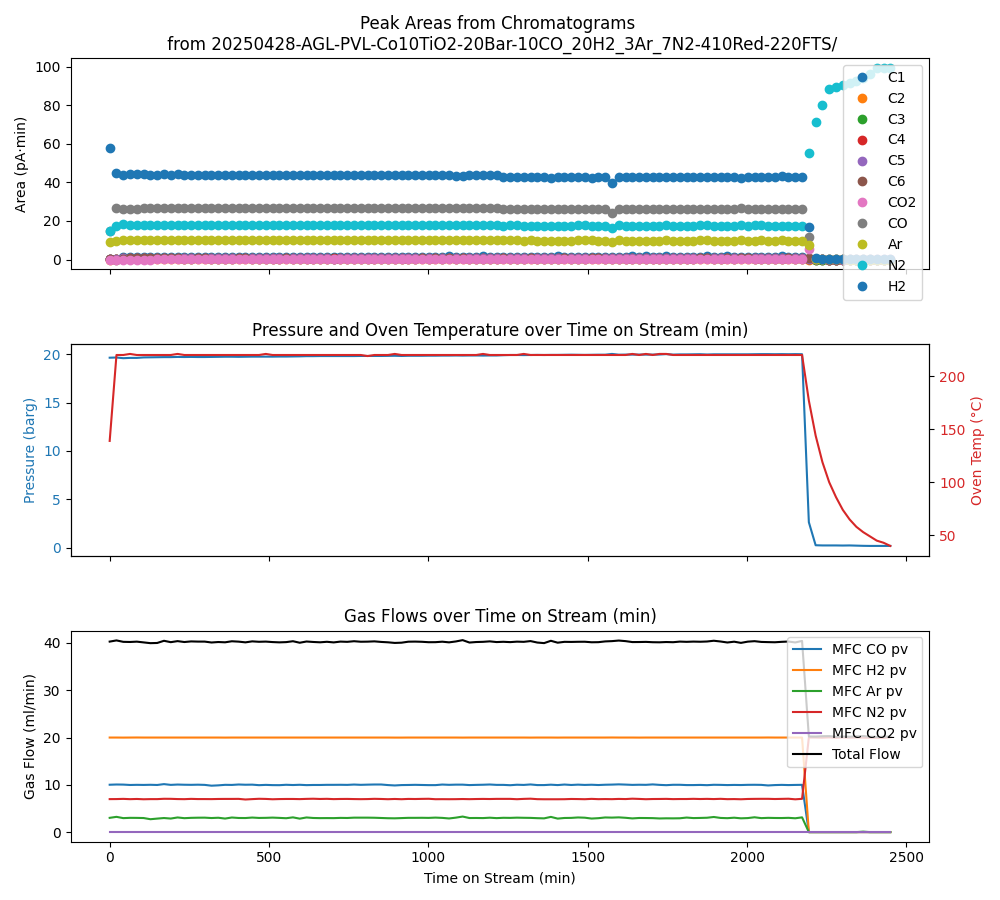

In [7]:
area_FID = exp_full.channels['FID'].integrate_peaksTP(peaklist=peak_dict['FID']).sort_values('Timestamp').set_index('Timestamp')
area_AuxLeft = exp_full.channels['TCD_AuxLeft'].integrate_peaksTP(peaklist=peak_dict['TCD_AuxLeft']).sort_values('Timestamp').set_index('Timestamp')
area_AuxRight = exp_full.channels['TCD_AuxRight'].integrate_peaksTP(peaklist=peak_dict['TCD_AuxRight']).sort_values('Timestamp').set_index('Timestamp')
area_totalDF = pd.concat([area_FID, area_AuxLeft, area_AuxRight], axis=1)
log_area_df = cs.add_log_data(area_totalDF.reset_index(), exp_full.log, columns = selected_columns)

# area_totalFig = plt.figure()
# area_totalFigAx = area_totalFig.add_subplot()
# for name in area_totalDF.columns:
#     area_totalFigAx.plot(area_totalDF[name], label=name, linestyle='', marker='o')
# area_totalFigAx.legend()
# area_totalFigAx.set_xlabel('datetime')
# area_totalFigAx.set_ylabel('Area (pA*min)')
# area_totalFigAx.title.set_text('Area of all integrations of sample: ' + experiment_name)
# area_totalFigAx.set_ylim(0,30)

fts.plot_comined_overview(
    combined_df=log_area_df,
    experiment_name=experiment_name,
    integration_gases=compound_list,
    gas_flow_columns=['MFC CO pv', 'MFC H2 pv', 'MFC Ar pv', 'MFC N2 pv', 'MFC CO2 pv'],
    plot_against='TOS'  # or 'datetime'
)

### Area to molar fraction faction (v/v%)
Converting the area into concentration factor (molar fraction) by using the calibration factor. This correciton is done by dividing the area of the peak by the calibration factor of that corresponding peak $i$. The value is a factor of the total gas flow output including reactants, products and inert.   
$$
y_{i} = \frac{A_{i}} {CF_{i}}
$$
$A_{i}$: Peak area of compound $i$   
$CF_{i}$: Calibration factor of compound $i$
 
The calibration factor hydrocarbon is the calibration factor of methane times the number of carbon atoms in the product:  
$$
CF_{C_x H_y,i} = {CF_{CH_4}} * {C_{i}}   
$$
${CF_{CH_4}}$: Calibration factor of methane   
${C_{i}}$: Number of carbon atoms in hydrocarbon

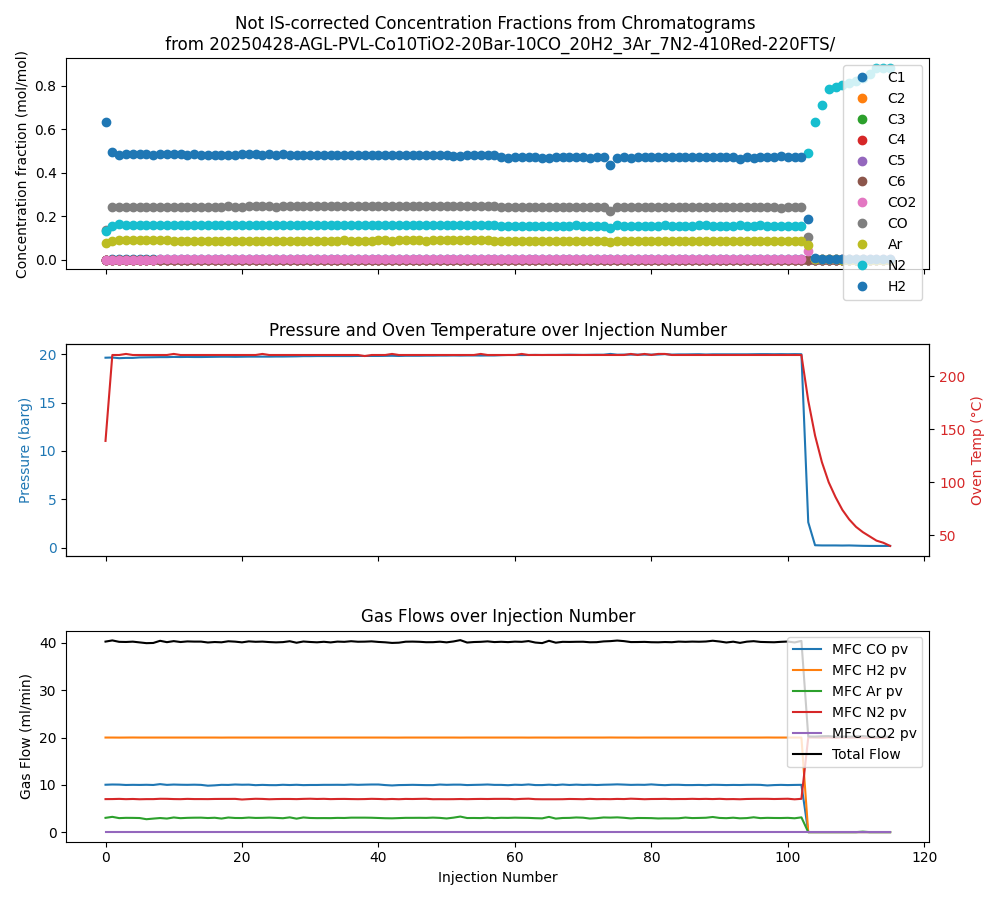

In [9]:
#Correction factors for the FTS setup for 40 ml/min of total gas flow
# Date: 01 april 2025
C1 = 705.88
FTCorrectionFactorsDict = {
'C1' : C1,
'C2' : C1 * 2,
'C3' : C1 * 3,
'C4' : C1 * 4,
'C5' : C1 * 5,
'C6' : C1 * 6,
'CO2': 134.56,
'CO' : 109.34,
'Ar' : 114.48,
'N2' : 112.57,
'H2' : 91
}
MolFrac_logDF = pd.DataFrame(index=log_area_df.index)
MolFrac_logDF = log_area_df.copy()
for name in compound_list:
    if name in log_area_df.columns:
        if name in FTCorrectionFactorsDict:
            MolFrac_logDF[name] = log_area_df[name] / FTCorrectionFactorsDict[name]
    else:
        print(f"Warning: Peak '{name}' not found in log_area_df.")
MolFrac_logDF.to_excel(data_home / 'MolFrac_with_log.xlsx')

# --- Plotting ----
fts.plot_comined_overview(
    combined_df=MolFrac_logDF,
    gas_flow_columns=['MFC CO pv', 'MFC H2 pv', 'MFC Ar pv', 'MFC N2 pv', 'MFC CO2 pv'],
    experiment_name=experiment_name,
    integration_gases=compound_list,
    plot_against='datatime',
    #xlim=(1000, 3200), # Adjust TOS x-axis limits as needed
    #ax1_ylim=(0, 0.01), # Adjust y-axis limits for chromatogram results as needed
    ax1_label='Concentration fraction (mol/mol)',
    ax1_title='Not IS-corrected Concentration Fractions from Chromatograms'
)

### Molar fraction to molar flow F_i (mol/min) with internal standard
The molar flow of each compound in [mol/min] is calculated by multiplying the molar fraction with the total flow out  $F_{tot,out}$ in mol/min. Due to gascontraction/expansion,  $F_{tot,in}$ is NOT equal to  $F_{tot,out}$. This can be corrected by calcalating  $F_{tot,out}$ based on the internal standaard (He, N2, or Ar) assuming  $F_{IS,in}$ =  $F_{IS,out}$    
$$
F_{tot,out} = \frac{y_{IS,in}*F_{tot,in}} {y_{IS,out,j}}
$$
$y_{IS,in}$: Molar faction of the internal standaard $IS$ between 0-1 before the reaction based of the MFC of $IS$ (e.g. 4 ml/min Ar in 40 ml/min total flow becomes 0.1)    
$F_{tot,in}$: Total molar flow into the reactor in mol/min based of the MFC's. The ml/min of the MFC's is converted to mol/min by using the ideal gas law n = PV/RT using STP   
$y_{IS,out,j}$: Molar fraction of the internal standaard $IS$ at injection $j$


To get the molar flow of each compound, simply multiply each molar fraction $y_{i,out}$ by $F_{tot,out}$ for every injection.   
$$
F_{i,out} = {y_{i,out}*F_{tot,out}} 
$$

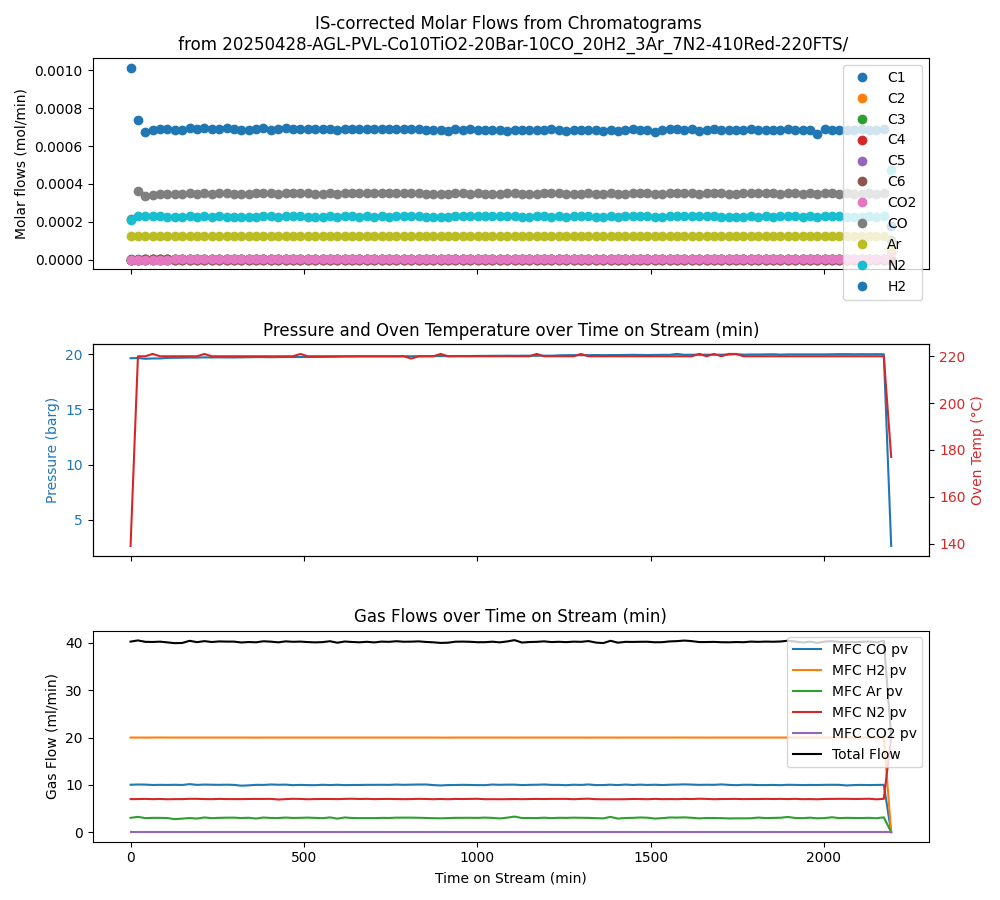

In [10]:
Reactant = "CO"
products = ["C1", "C2", "C3", "C4", "CO2", "C5+"]
ReactantConc = metadata['reactant_conc']
IntStand = metadata['IntStand']
ISConc = metadata['ISConc']
P_std = 1.0132525  # Standard pressure in bar
T_std = 20  # Standard temperature in celcius (20°C)

is_logDF = MolFrac_logDF.copy()
is_logDF['GasContractionFactor'] = is_logDF[IntStand] / ISConc # Compute Gas Contraction Factor
is_logDF = is_logDF[is_logDF['GasContractionFactor'] > 0.1]
is_logDF['Ftot,in'] = fts.calculate_molar_flow(is_logDF['Total Flow'], p=P_std, T=T_std)  # Molar flow in mol/min
is_logDF['Ftot,out'] = is_logDF['Ftot,in'] / is_logDF['GasContractionFactor']  # Molar flow out adjusted for gas contraction
for col in compound_list: #Apply internal standard correction only to peak_names
    if col in is_logDF.columns:
        is_logDF[col] = is_logDF[col] * is_logDF['Ftot,out'] # Convert to molar flow (mol/min)

fts.plot_comined_overview(
    combined_df=is_logDF,
    gas_flow_columns=['MFC CO pv', 'MFC H2 pv', 'MFC Ar pv', 'MFC N2 pv', 'MFC CO2 pv'],
    experiment_name=experiment_name,
    integration_gases=compound_list,
    #plot_against='TOS',
    #xlim=(1000, 3200), # Adjust TOS x-axis limits as needed
    #ax1_ylim=(0, 0.002), # Adjust y-axis limits for chromatogram results as needed
    ax1_label='Molar flows (mol/min)',
    ax1_title='IS-corrected Molar Flows from Chromatograms'
)



### Space-time-yield and selectivity calculations

#### Conversion
The product-based conversion on the reacts is calcuated with `fts.calculate_conversion_based_on_reactant()`. 
$$
X_{CO_{x}} = \frac{CO_{x,in}-CO_{x,out}} {CO_{x,in}} *100 \%
$$
${CO_{x,in}}$: The molar flow of COx into the reactor [mol/min]. This is a constant calculated based of the MFCs molar fraction as `ReactantConc[Reactant]` and converted to molar flow.   
${CO_{x,out}}$: The molar flow of COx out of the reactor to the GC [mol/min]. This value is based of the TCD signal of the CO in your chromatograms.   

The product-based conversion of product `i` is calculated in a similar fashion with `fts.calculate_product_conversion()`
$$
X_{i} = (1-\frac{CO_{x,in}-F_{i,out}} {CO_{x,in}})*100 \%
$$

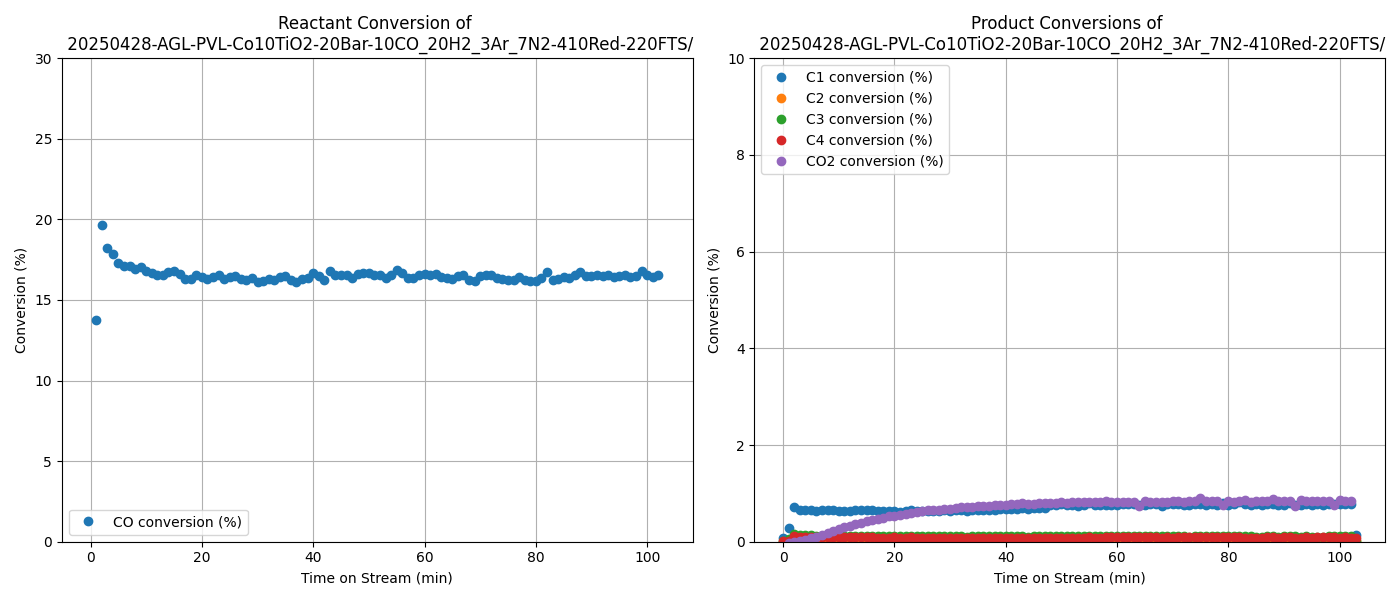

In [11]:
Reactant = "CO"
products = ["C1", "C2", "C3", "C4", "CO2"]


# Calculate conversions
ReactantConversion = fts.calculate_conversion_based_on_reactant(is_logDF, Reactant, ReactantConc[Reactant], total_flow='Ftot,in')
conversion_df = fts.calculate_product_conversions(is_logDF, products, ReactantConc[Reactant])

# Combine into one DataFrame
ConversionsDF = pd.concat([ReactantConversion, conversion_df], axis=1)

# Save to Excel
ConversionsDF.to_excel(data_home / "all_conversions.xlsx")


# -------------------------
# Plotting: side by side
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# Plot reactant conversion
axes[0].plot(ReactantConversion.index, ReactantConversion, linestyle="", marker="o", label=ReactantConversion.name)
axes[0].set_title(f"Reactant Conversion of \n {experiment_name}")
axes[0].set_xlabel("Time on Stream (min)")
axes[0].set_ylabel("Conversion (%)")
axes[0].set_ylim(0, 30)
#axes[0].set_xlim(0, 550)
axes[0].legend()
axes[0].grid(True)

# Plot product conversions
for col in conversion_df.columns:
    axes[1].plot(conversion_df.index, conversion_df[col], linestyle="", marker="o", label=col)
axes[1].set_title(f"Product Conversions of \n {experiment_name}")
axes[1].set_xlabel("Time on Stream (min)")
axes[1].set_ylabel("Conversion (%)")
axes[1].set_ylim(0, 10)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

#### Cobalt time yield
The space time yield of cobalt (CTY) quantifies the hydrocarbon productivity per gram of cobalt per unit time [mol COx/gCo/s]. This code calculates it for each injection:
$$
CTY = \frac{F_{CO_{x},out}*(\frac{X_{COx}}{100})} {m_{Co}} 
$$
$F_{CO_{x},out}$: Molar flow  of ${CO_x}$ in mol/min. Calculated based of the MFC of ${CO_x}$ using the ideal gas law at STP   
$X_{COx}$: ${CO_x}$ conversion in \%  
$m_{Co}$: The mass of the metallic cobalt. Based of the wt.\% of Co/TiO2

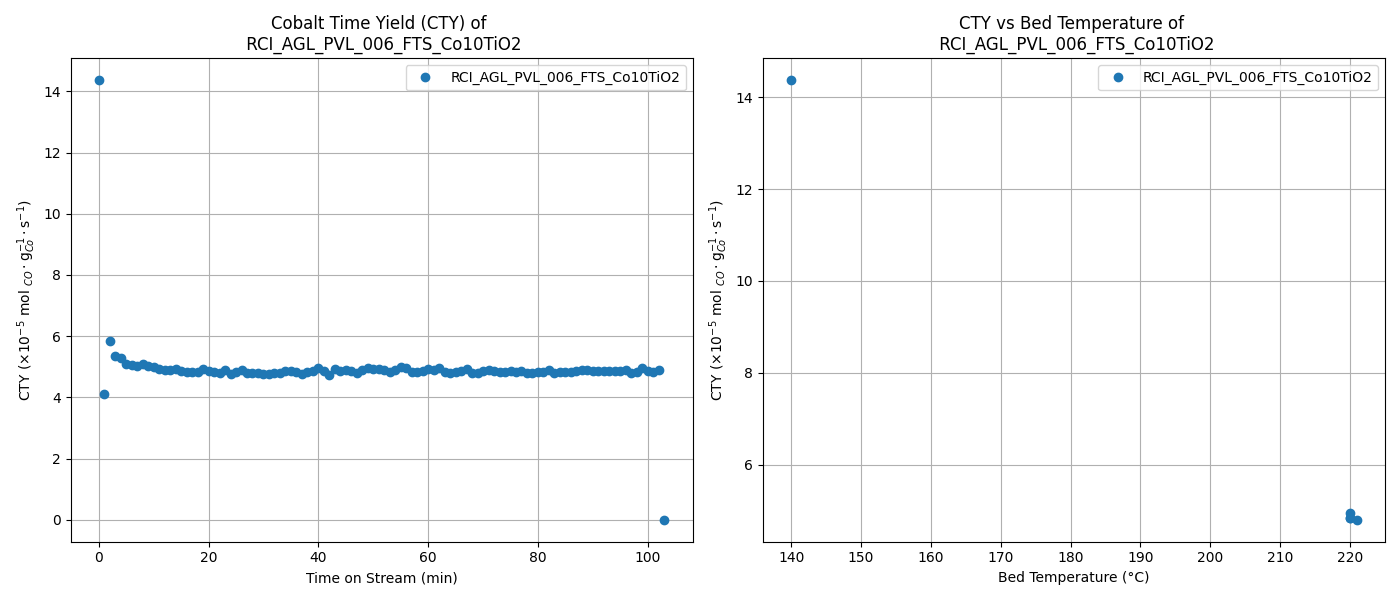

In [15]:
processed_data_path = r'C:\Users\6855245\OneDrive - Universiteit Utrecht\PhD\Results\FTS catalytic tests\Processed_data\raw_data/'
all_metadata = fts.load_experiment_metadata(r'C:/Users/6855245/OneDrive - Universiteit Utrecht/PhD/Results/FTS catalytic tests/Processed_data/raw_data/FTS_Robin_metadata.yaml')


# Getting the desired experiment data
experiment = current_experiment # Or use current_experiment to load the same experiment as before
mass_Co = all_metadata[experiment]["catalyst"]["weight"] * all_metadata[experiment]["catalyst"]["Co_loading"]/100 # weight catalyst in reactor [gram] * wt% Co 
data_home = Path(metadata['root']) / metadata['folder_name'] 
data_Log = pd.read_excel(data_home / 'Amounts_iscorr+log_factor_between_0and1.xlsx', index_col=0)
conversions = pd.read_excel(data_home / 'all_conversions.xlsx', index_col=0)
data = pd.concat([data_Log, conversions], axis=1)

# Calculate CO_in (molCO/s) and CTY (molCO*gCo^-1*s^-1) for each injection 
data['CO_in (molCO/s)'] =  fts.calculate_molar_flow(is_logDF['MFC CO pv'], p=P_std, T=T_std) / 60  # mol/s
data['CTY'] = data['CO_in (molCO/s)'] * (data['CO conversion (%)']/100) / mass_Co # (molCO*gCo^-1*s^-1)
data['CTY_scaled'] = data['CTY']*100000 # (x10^(-5) molCO*gCo^-1*s^-1)
data.to_excel(data_home  / f"all_results_{experiment}.xlsx")

# -------------------------
# Plotting: side by side
# -------------------------
fig, (axTime, axTemp) = plt.subplots(1, 2, figsize=(14, 6))
# Plot CTY over TOS
axTime.plot(data.index, data['CTY_scaled'], linestyle="", marker="o", label=experiment)
axTime.set_title(f"Cobalt Time Yield (CTY) of \n {experiment}")
#axTime.set_ylim(0, 100)
axTime.set_xlabel("Time on Stream (min)")
axTime.set_ylabel(r"CTY ($\times 10^{-5}$ mol $_{CO}\cdot$g$_{Co}^{-1}\cdot$s$^{-1}$)")
axTime.legend()
axTime.grid(True)

# Plot CTY over temperature
axTemp.plot(data['Oven PV'], data['CTY_scaled'], linestyle="", marker="o", label=experiment)
axTemp.set_title(f"CTY vs Bed Temperature of \n {experiment}")
axTemp.set_xlabel("Bed Temperature (°C)")
axTemp.set_ylabel(r"CTY ($\times 10^{-5}$ mol $_{CO}\cdot$g$_{Co}^{-1}\cdot$s$^{-1}$)")
axTemp.legend()
axTemp.grid(True)

plt.tight_layout()
plt.show()

#### Selectivity
This is how to calculate the carbon-based selectivity

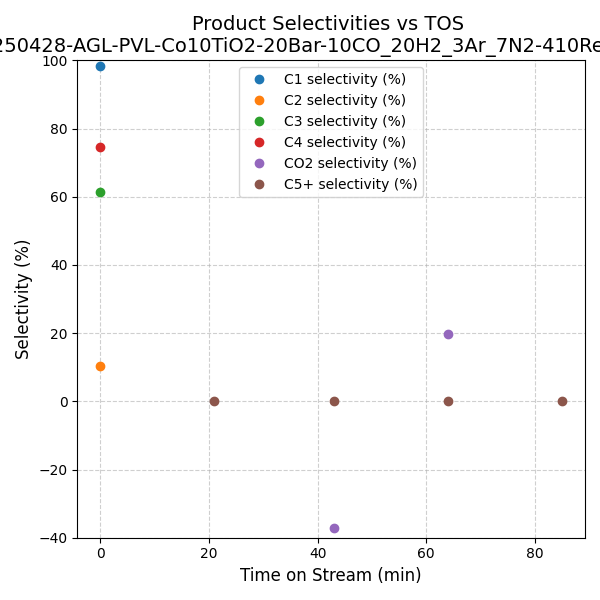

In [16]:
C_conv = data['CO_in (molCO/s)'] * 60 * (data['CO conversion (%)'] / 100)  # already in mol/s
 # Carbon contributions (mol C/min)
C_C1 = data["C1"] * 1
C1_mass = C_C1 * 16.043 # g/min
C_C2 = data["C2"] * 2
C2_mass = C_C2 * 30.07 # g/min
C_C3 = data["C3"] * 3
C3_mass = C_C3 * 44.097 # g/min
C_C4 = data["C4"] * 4
C4_mass = C_C4 * 58.124 # g/min
C_CO2 = data["CO2"] * 1
CO2_mass = C_CO2 * 44.01 # g/min
 
C2_C4Mol = C_C2 + C_C3 + C_C4
C2_C4Mass = C2_mass + C3_mass + C4_mass
# C5+ by difference
C_C5p = C_conv - (C_C1 + C_C2 + C_C3 + C_C4 + C_CO2)
C_C5p = C_C5p.clip(lower=0)
 
# Build selectivity DataFrame
selectivity_df = pd.DataFrame(index=data.index)
selectivity_df['C1 selectivity (%)'] = (C_C1 / C_conv) * 100
selectivity_df['C2 selectivity (%)'] = (C_C2 / C_conv) * 100
selectivity_df['C3 selectivity (%)'] = (C_C3 / C_conv) * 100
selectivity_df['C4 selectivity (%)'] = (C_C4 / C_conv) * 100
selectivity_df['CO2 selectivity (%)'] = (C_CO2 / C_conv) * 100
selectivity_df['C5+ selectivity (%)'] = (C_C5p / C_conv) * 100
selectivity_df.to_excel(data_home / "Selectivities.xlsx")
 
plt.figure(figsize=(6, 6))
for col in selectivity_df.columns:
    plt.plot(selectivity_df.index, selectivity_df[col], marker='o', linestyle='', label=col)
plt.xlabel("Time on Stream (min)", fontsize=12)
plt.ylabel("Selectivity (%)", fontsize=12)
plt.title(f"Product Selectivities vs TOS \n {experiment_name}", fontsize=14)
plt.legend()
plt.ylim(-40,100)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

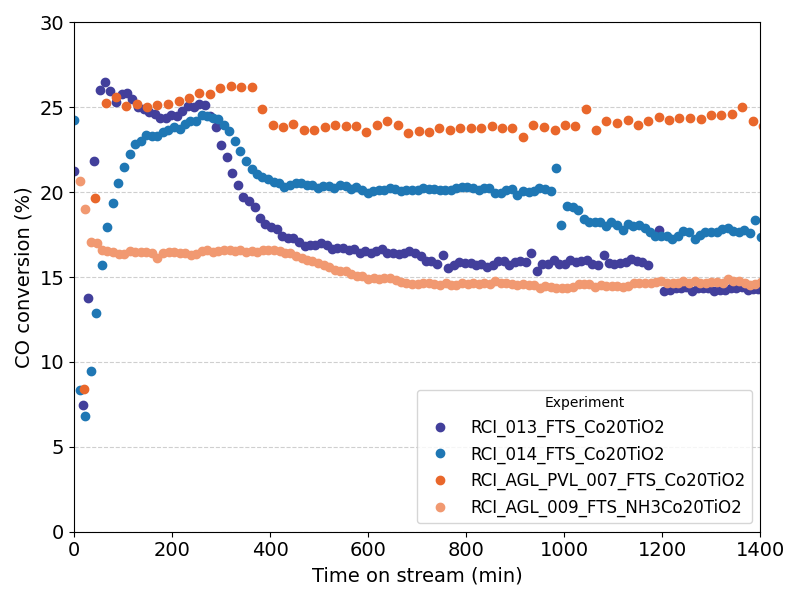

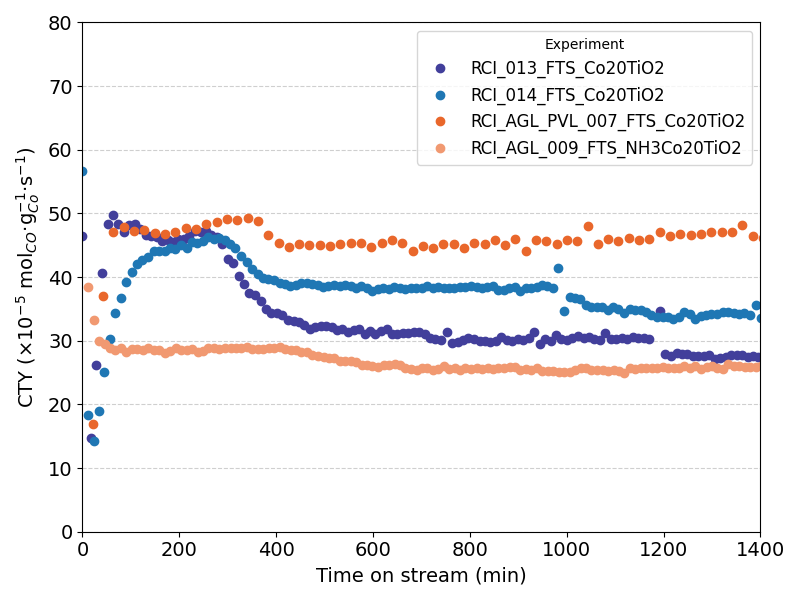

In [17]:
processed_data_path = r"C:\Users\6855245\OneDrive - Universiteit Utrecht\PhD\Results\FTS catalytic tests\Processed_data\raw_data"
metadata_path = os.path.join(processed_data_path, "FTS_Robin_metadata.yaml")

experiments_to_plot = [
    #"RCI_AGL_PVL_006_FTS_Co10TiO2",
    #"RCI_AGL_012_FTS_NH3Co10TiO2",
    'RCI_013_FTS_Co20TiO2',
    'RCI_014_FTS_Co20TiO2',
    "RCI_AGL_PVL_007_FTS_Co20TiO2",
    "RCI_AGL_009_FTS_NH3Co20TiO2",
]

colors = {
    "RCI_013_FTS_Co20TiO2": "#423f9b",
    "RCI_AGL_012_FTS_NH3Co10TiO2": "#6faad1",
    "RCI_AGL_PVL_007_FTS_Co20TiO2": "#E9672B",
    "RCI_AGL_009_FTS_NH3Co20TiO2": "#F19971",
}


bar_colors = ["#2B5777", "#6faad1", "#E9672B", "#F19971"]
# --- Plot CO conversion ---
fts.plot_experiment_results(
    metadata_path=metadata_path,
    experiments=experiments_to_plot,
    column="CO conversion (%)",
    ylabel="CO conversion (%)",
    xlim=(0, 1400),
    ylim=(0, 30),
    colors=colors
)

plt.savefig(r"C:\Users\6855245\OneDrive - Universiteit Utrecht\PhD\Poster\poster figures svg\CTY_comparison.svg", dpi=300)
# --- Plot CTY ---
fts.plot_experiment_results(
    metadata_path=metadata_path,
    experiments=experiments_to_plot,
    column="CTY_scaled",
    ylabel=r"CTY ($\times 10^{-5}$ mol$_{CO}$·g$_{Co}^{-1}$·s$^{-1}$)",
    xlim=(0, 1400),
    ylim=(0,80),
    colors=colors
)

Other useful things not really working made by ChatGPT

In [ ]:
def calculate_conversion(df, reactant, reactant_inlet_conc, total_flow_in_col='Ftot,in', reactant_col=None):
    if reactant_col is None:
        reactant_col = reactant
    # Conversion = (F_in * x_in - F_out * x_out) / (F_in * x_in)
    return 100 * (1 - (df[reactant_col] / (reactant_inlet_conc * df[total_flow_in_col])))

def calculate_selectivity(df, reactant, products, carbon_numbers, total_flow_in_col='Ftot,in'):
    """
    df: DataFrame containing molar flows of reactant and products
    reactant: name of reactant column (e.g. 'CO')
    products: list of product names (e.g. ['CH4', 'C2H6', 'C3H8', 'CO2'])
    carbon_numbers: dict like {'CH4':1, 'C2H6':2, 'C3H8':3, 'CO2':1}
    """
    selectivities = {}
    carbon_out = sum(df[p] * carbon_numbers.get(p, 1) for p in products if p in df.columns)
    carbon_in = df[reactant] * carbon_numbers.get(reactant, 1)
    for p in products:
        if p in df.columns:
            selectivities[p] = 100 * (df[p] * carbon_numbers.get(p, 1) / carbon_out)
    selectivity_df = pd.DataFrame(selectivities, index=df.index)
    selectivity_df['ΣC_balance'] = 100 * carbon_out / carbon_in
    return selectivity_df

def analyze_FTS_conversion_selectivity(df, metadata):
    reactant = metadata['reactant']
    products = metadata['products']
    reactant_conc = metadata['reactant_conc'][reactant]

    conv = calculate_conversion(df, reactant, reactant_conc)
    sel = calculate_selectivity(df, reactant, products, metadata['carbon_numbers'])
    return pd.concat({'Conversion': conv, 'Selectivity': sel}, axis=1)

def calculate_CO_conversion_and_selectivity(df, calibration_factors, internal_standard='Ar'):
    """
    Calculate CO conversion and selectivities based on integrated peak areas.

    Parameters:
        df (pd.DataFrame): DataFrame with integrated peak areas (e.g., CO, CO2, CH4, C2H6, C3H8, Ar).
        calibration_factors (dict): Dict mapping compound → calibration factor (area → molar flow).
        internal_standard (str): Name of the inert internal standard (e.g. 'Ar').

    Returns:
        pd.DataFrame: DataFrame with columns:
            - CO_conversion (%)
            - Selectivity_CO2 (%)
            - Selectivity_CH4 (%)
            - Selectivity_C2+ (%)
    """
    df_calc = df.copy()

    # Normalize all by internal standard
    for comp in calibration_factors:
        df_calc[f"{comp}_norm"] = (df_calc[comp] / df_calc[internal_standard]) * calibration_factors[comp]

    # Compute CO conversion
    df_calc["CO_conversion (%)"] = (1 - df_calc["CO_norm"] / df_calc["CO_norm"].iloc[0]) * 100

    # Compute C-based selectivities
    carbon_counts = {"CO2": 1, "CH4": 1, "C2H6": 2, "C3H8": 3}
    total_C_out = sum(df_calc[f"{c}_norm"] * nC for c, nC in carbon_counts.items() if f"{c}_norm" in df_calc)

    for c, nC in carbon_counts.items():
        if f"{c}_norm" in df_calc:
            df_calc[f"Selectivity_{c} (%)"] = (df_calc[f"{c}_norm"] * nC / total_C_out) * 100

    return df_calc

